# Formartar números

In [2]:
def formatar (valor):
  return f"R${valor:,.2f}"

#1. Análise do faturamento

---





### Importação dos dados



In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)


In [4]:
import pandas as pd

loja["loja"] = "Loja 1"
loja2["loja"] = "Loja 2"
loja3["loja"] = "Loja 3"
loja4["loja"] = "Loja 4"

df_final = pd.concat(
    [loja, loja2, loja3, loja4],
    ignore_index=True
)

df_final.head()


,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon,loja
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79,Loja 1
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66,Loja 1
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86,Loja 1
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50,Loja 1
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38,Loja 1


In [5]:
df_final.shape

(9435, 13)

In [6]:
faturamento = df_final.groupby('loja')['Preço'].sum()
faturamento.apply(formatar)

,Preço
loja,
Loja 1,"R$1,534,509.12"
Loja 2,"R$1,488,459.06"
Loja 3,"R$1,464,025.03"
Loja 4,"R$1,384,497.58"


# 2. Vendas por Categoria

In [7]:
loja_cat = loja.groupby('Categoria do Produto')['Preço'].sum().sort_values(ascending=False)
loja_cat
def formatar (valor):
  return f"R${valor:,.2f}"

loja_cat.apply(formatar)

,Preço
Categoria do Produto,
eletronicos,"R$572,659.23"
eletrodomesticos,"R$484,913.36"
moveis,"R$250,178.11"
instrumentos musicais,"R$121,731.69"
esporte e lazer,"R$52,387.55"
brinquedos,"R$23,993.78"
utilidades domesticas,"R$16,931.48"
livros,"R$11,713.92"


In [8]:
# Criar uma tabela dinâmica:
# Index (linhas): 'Categoria do Produto'
# Columns (colunas): 'loja'
# Values (valores na tabela): 'Preço'
# aggfunc (função de agregação): 'sum' (soma dos valores)
tabela_dinamica = df_final.pivot_table(index='Categoria do Produto', columns='loja', values='Preço', aggfunc='sum').sort_values(by="Loja 1",ascending= False)

print(tabela_dinamica)

loja                      Loja 1     Loja 2     Loja 3     Loja 4
Categoria do Produto                                             
eletronicos            572659.23  547773.71  547699.92  545966.86
eletrodomesticos       484913.36  464758.13  438984.89  377680.65
moveis                 250178.11  235234.68  268095.56  256705.65
instrumentos musicais  121731.69  139987.03  103174.45  100136.50
esporte e lazer         52387.55   46326.09   47456.10   44465.65
brinquedos              23993.78   21262.21   25869.20   27015.67
utilidades domesticas   16931.48   19662.86   20080.21   20098.83
livros                  11713.92   13454.35   12664.70   12427.77


# 3. Média de Avaliação das Lojas


In [9]:
scores = df_final.groupby('loja')['Avaliação da compra'].mean()
display(scores)

,Avaliação da compra
loja,
Loja 1,3.976685
Loja 2,4.037304
Loja 3,4.048326
Loja 4,3.995759


# 4. Produtos Mais e Menos Vendidos

In [10]:
sell_products = df_final.groupby('Produto')['Produto'].count().sort_values(ascending=False)
display(sell_products.head(10),sell_products.tail(10))

,Produto
Produto,
Cômoda,210
Carrinho controle remoto,206
Micro-ondas,206
Bateria,203
Cama king,201
Jogo de panelas,200
Modelagem preditiva,200
Secadora de roupas,200
Blocos de montar,199


,Produto
Produto,
Smartwatch,172
Panela de pressão,172
Jogo de copos,169
Poltrona,168
Assistente virtual,167
Ciência de dados com python,166
Guitarra,165
Mochila,163
Headset,158


In [14]:
contagem = (
    df_final
    .groupby(["Categoria do Produto", "Produto",'loja'])
    .size()
    .reset_index(name="qtd_vendas")
)
sells_lojas = contagem.pivot_table(index = "Produto", columns = "loja", values = "qtd_vendas", aggfunc = "sum").sort_values(by='Loja 1',ascending=False)
sells_lojas.head(10)

loja,Loja 1,Loja 2,Loja 3,Loja 4
Produto,,,,
TV Led UHD 4K,60,45,42,40
Micro-ondas,60,62,36,48
Guarda roupas,60,54,49,34
Secadora de roupas,58,57,45,40
Blocos de montar,56,54,35,54
Cômoda,56,44,55,55
Bola de basquete,55,42,50,50
Bicicleta,54,45,52,45
Copo térmico,54,47,38,48


# 5. Frete Médio por Loja

In [12]:
freight = df_final.groupby('loja')['Frete'].mean()
freight.apply(formatar)

,Frete
loja,
Loja 1,R$34.69
Loja 2,R$33.62
Loja 3,R$33.07
Loja 4,R$31.28


In [13]:
max = df_final['Quantidade de parcelas'].max()
print(max)

24


In [37]:
faturamento_loja_mes = (
    df_final
    .groupby([
        df_final["Data da Compra"].dt.to_period("M"),
        "loja"
    ])["Preço"]
    .sum()
    .reset_index()
)

# Converter Period para timestamp (melhor para gráficos)
faturamento_loja_mes["Data da Compra"] = (
    faturamento_loja_mes["Data da Compra"].dt.to_timestamp()
)



In [40]:
faturamento_loja_mes.groupby("loja")["Preço"].mean()

,Preço
loja,
Loja 1,39346.387692
Loja 2,38165.616923
Loja 3,37539.103333
Loja 4,35499.937949


In [41]:
from folium.plugins import HeatMap

heat_data = df_final[["lat", "lon"]].values.tolist()

HeatMap(heat_data).add_to(mapa)

mapa


NameError: name 'mapa' is not defined

In [42]:
import folium
from folium.plugins import HeatMap
import pandas as pd

# -------------------------------------------------
# 1️⃣ Garantir que lat e lon são numéricos
# -------------------------------------------------
df_final["lat"] = pd.to_numeric(df_final["lat"], errors="coerce")
df_final["lon"] = pd.to_numeric(df_final["lon"], errors="coerce")

df_final = df_final.dropna(subset=["lat", "lon"])

# -------------------------------------------------
# 2️⃣ Criar mapa base (centro médio dos dados)
# -------------------------------------------------
mapa = folium.Map(
    location=[
        df_final["lat"].mean(),
        df_final["lon"].mean()
    ],
    zoom_start=6,
    tiles="OpenStreetMap"
)

# -------------------------------------------------
# 3️⃣ Cores por loja
# -------------------------------------------------
cores_lojas = {
    loja: cor for loja, cor in zip(
        df_final["loja"].unique(),
        ["red", "blue", "green", "purple", "orange", "darkred"]
    )
}

# -------------------------------------------------
# 4️⃣ Adicionar pontos de venda (scatter no mapa)
# -------------------------------------------------
for _, row in df_final.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=4,
        popup=f"""
        Loja: {row['loja']}<br>
        Produto: {row.get('Produto', 'N/A')}<br>
        Faturamento: {row.get('Preço', 'N/A')}
        """,
        color=cores_lojas.get(row["loja"], "gray"),
        fill=True,
        fill_opacity=0.6
    ).add_to(mapa)

# -------------------------------------------------
# 5️⃣ Heatmap — concentração de vendas
# -------------------------------------------------
heat_data = df_final[["lat", "lon"]].values.tolist()

HeatMap(
    heat_data,
    radius=15,
    blur=10,
    min_opacity=0.4
).add_to(mapa)

# -------------------------------------------------
# 6️⃣ Salvar mapa interativo
# -------------------------------------------------
mapa.save("mapa_geografico_vendas.html")

# -------------------------------------------------
# 7️⃣ Exibir mapa (Jupyter / Colab)
# -------------------------------------------------
mapa


Output hidden; open in https://colab.research.google.com to view.

<Figure size 640x480 with 0 Axes>

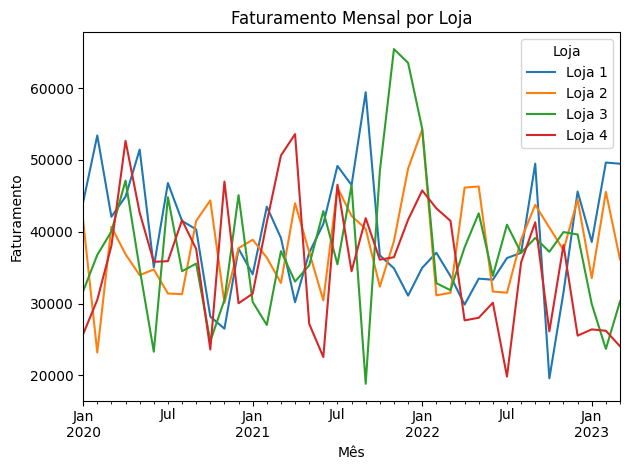

In [38]:
pivot = faturamento_loja_mes.pivot(
    index="Data da Compra",
    columns="loja",
    values="Preço"
)
import matplotlib.pyplot as plt

plt.figure()
pivot.plot()
plt.title("Faturamento Mensal por Loja")
plt.xlabel("Mês")
plt.ylabel("Faturamento")
plt.legend(title="Loja")
plt.tight_layout()
plt.show()


In [21]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9435 entries, 0 to 9434
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Produto                 9435 non-null   object 
 1   Categoria do Produto    9435 non-null   object 
 2   Preço                   9435 non-null   float64
 3   Frete                   9435 non-null   float64
 4   Data da Compra          9435 non-null   object 
 5   Vendedor                9435 non-null   object 
 6   Local da compra         9435 non-null   object 
 7   Avaliação da compra     9435 non-null   int64  
 8   Tipo de pagamento       9435 non-null   object 
 9   Quantidade de parcelas  9435 non-null   int64  
 10  lat                     9435 non-null   float64
 11  lon                     9435 non-null   float64
 12  loja                    9435 non-null   object 
dtypes: float64(4), int64(2), object(7)
memory usage: 958.4+ KB


In [23]:
df_final["Data da Compra"] = pd.to_datetime(df_final["Data da Compra"], errors="coerce")


/tmp/ipython-input-2362723307.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_final["Data da Compra"] = pd.to_datetime(df_final["Data da Compra"], errors="coerce")


In [25]:
df_final["Data da Compra"] = pd.to_datetime(
    df_final["Data da Compra"],
    format="%d/%m/%Y",
    errors="coerce"
)
df_final.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9435 entries, 0 to 9434
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Produto                 9435 non-null   object        
 1   Categoria do Produto    9435 non-null   object        
 2   Preço                   9435 non-null   float64       
 3   Frete                   9435 non-null   float64       
 4   Data da Compra          9435 non-null   datetime64[ns]
 5   Vendedor                9435 non-null   object        
 6   Local da compra         9435 non-null   object        
 7   Avaliação da compra     9435 non-null   int64         
 8   Tipo de pagamento       9435 non-null   object        
 9   Quantidade de parcelas  9435 non-null   int64         
 10  lat                     9435 non-null   float64       
 11  lon                     9435 non-null   float64       
 12  loja                    9435 non-null   object  